# Homework 2
### ASTR 324, Spring 2026, Ivezic, University of Washington

https://github.com/uw-astr-324/astr-324-s26


## Homework submission procedure: 

* You will be sending me your executed (with all the plots etc) *.ipynb files via email

* the Subject: line **must be** "astr-324-s26-FirstLast-HW?, where FirstLast is your first
and last name, and ? will be 1, 2, 3 or 4. 

* For example: astr-324-s26-ZeljkoIvezic-HW1

* I will be recognizing and downloading your submissions using a script. If you don't 
follow the above, your HW will not be recognized.

* Your homework email **must be sent** before Thursday class (that is, before 10am)
two weeks after that homework was assigned (e.g. HW1 will be available by the start of Thursday 
class on April 9, and will be due by 10am on April 23).

 


## Problem 1

We learned this week that the posterior pdf for $b$, the tail probability when
flipping a coin, with a flat prior in the range 0-1, is
$$ p(b \,|\, k, N ) = C \, b^k \, (1-b)^{N-k}, $$
where the normalization constant $C$ can be determined from the condition $\int_0^1 p(b\,|\,k,N)\, db = 1$.

Get a REAL coin, flip it 10 times and record your results.

a) plot $p(b \,|\, k, N )$ after each flip. Every time show the previous (prior) $p(b)$
and the posterior $p(b)$ (there is an example code in Week4 lecture).

b) After all 10 flips, what is the probability that your coin strongly prefers
heads or tails: what is the probability [$p(b<0.45\,|\, k, N )$ OR $p(b>0.55\,|\, k, N )$)] ? 



## Problem 2

Now simulate a coin with $b_\ast = 0.4$. Using code provided in lecture (Week 4), draw a sample of 800 flips. 
Show (plot!) the evolution of $p(b \,|\, k, N )$ after each 100 flips. Alternatively, you can make an animated
gif file (google it!) with all 800 steps (say, 0.05 sec per frame for a 40 sec video clip). 
If we define a "fair" coin as $0.49 < b < 0.51$, what is the probability that this coin is NOT fair given this dataset of 800 flips? 


## Problem 3
Fit polynomials of up to the 10th order to the provided dataset (see below). Show the plot using the code from class as a template. Use BIC to find the best model for this dataset. Is it decisively better than the 2nd best model? 
What about the 3rd best model? What are the values of $\chi^2$ per degree of freedom for the 3 best models?
What do you conclude about selection of the best-fit model in this case? 


## Problem 4

I measured the size of a killer asteroid 3 times and obtained 90, 100, and 120 meters. What is the probability
that this asteroid is larger than 140 meters? What is the result when you naively use Gaussian distribution instead of Student's t distribution? Plot both distributions. Would you bet 1 to 20 that this asteroid is smaller than 140 meters, which is (somewhat artificial) limit for extremely deadly impactors? 

## Problem 5

These questions are similar to those that you will be asked on the final exam. Please answer each one with 1-3 sentences. 

* State what is the probability of model $M$ given some dataset $D$, using Bayes' Theorem: $p(M|D) =....$

* State Bayes' Theorem by explicitly mentioning the vector of model parameters $\theta$ and prior information $I$: 
$p(M, \theta|D,I) =....$

* What does prior probability distribution in Bayesian statistics describe?  

* What is posterior probability distribution in Bayesian statistics describe? 

* We can expand prior probability distribution $p(M, \theta|I) = XXX \,\, p(M|I)$. What is $XXX$ here? 

* If prior probability distribution is described by a wide gaussian and the data likelihood is 
described by a narrow(er) gaussian, how does the posterior probability distribution look like (comment on its location and width relative to locations and widths of prior and likelihood)? 


* When we have no information about prior probability distributions, what should we adopt for priors in case of location and scale parameters? 


* What are nuisance parameters in Bayesian statistics? 

* What is marginalization in Bayesian statistics? 

* You are given posterior probability distribution as a function of k model parameters. What will derivatives of this distribution with respect to each model parameter give you? 

* You are given posterior probability distribution as a function of k model parameters. What will the intergral of this function over all model parameters give you? 

* State the Bayesian Information Criterion and explain what it is good for. 


# Homework 2: Solutions

### Some useful definitions and functions

In [1]:
import numpy as np 
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy import stats
from scipy import optimize
np.random.seed(5967)

Write your solutions below...

## Problem 1

results for my coin (0:head, 1: tail):
[0, 1, 1, 1, 0, 0, 0, 1, 0, 0]

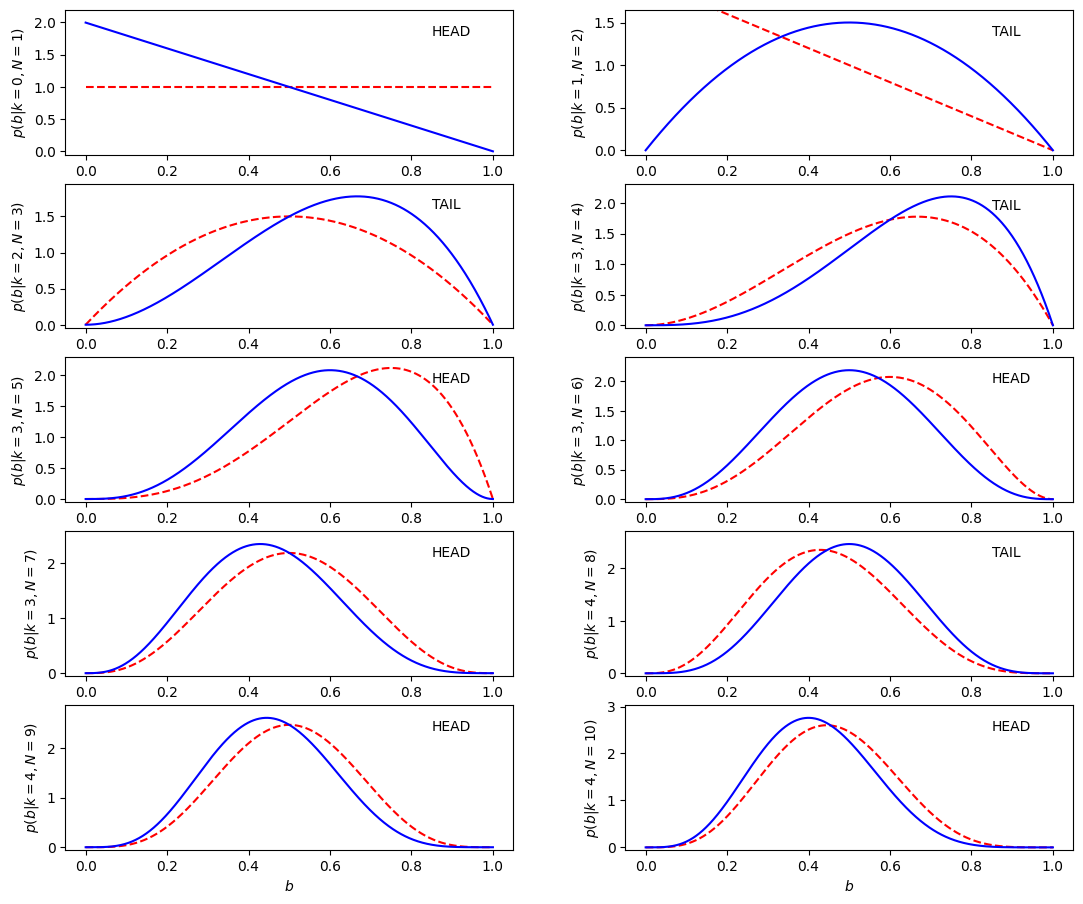

p(b<0.45):  0.6041716237007119


In [2]:
# results for my coin
flipData = [0, 1, 1, 1, 0, 0, 0, 1, 0, 0]

# plotting setup 
fig = plt.figure(figsize=(12, 12))
fig.subplots_adjust(left=0.11, right=0.95, wspace=0.25, bottom=0.18)
 
# b grid for computing p(b) 
b = np.linspace(0,1,1000)
db = b[1]-b[0]
# prior 
p_b = 1.0 + 0*b   # flat prior

# loop over data
for i in range(1,11):
    ax = fig.add_subplot(5,2, int(i))
    # show p_b before this data point is added
    ax.plot(b, p_b, '--r')
    # now get new p_b
    N = i 
    k = flipData[0:i].count(1)
    p_b = b ** k * (1 - b) ** (N - k)
    p_b /= p_b.sum()
    p_b /= db
    # p_b after this data point is added
    label=' z'
    ax.plot(b, p_b, '-b', label=label)
    ax.set_xlabel('$b$')
    s = '$p(b|k=%i' % k
    s = s + ', N=%i)$' % N
    if (flipData[i-1] == 0): 
        ax.text(0.85, np.max(p_b)*0.9,'HEAD')
    else:
        ax.text(0.85, np.max(p_b)*0.9,'TAIL')
    ax.set_ylabel(s)
    ax.set_ylim(-0.05, np.max(p_b)*1.1)
    
plt.show()

cuml_p_b = p_b.cumsum()
cuml_p_b /= cuml_p_b[-1]
print('p(b<0.45): ', np.interp(0.45, b, cuml_p_b)) 

p(b<0.45|k, N) is 0.604

## Problem 2

In [3]:
# results for my coin
np.random.seed(42) 
flipData = (stats.bernoulli.rvs(0.4, size=800)).tolist()

# plotting setup 
# fig, ax = plt.subplots(figsize=(10, 8))
fig.subplots_adjust(left=0.15, right=0.95, bottom=0.15, top=0.9)
b = np.linspace(0, 1, 1000)

# blank line that we will update
line, = ax.plot([], [], '-b', lw=2)

ax.set_xlabel('b')
ax.set_xlim(0, 1)

def update(frame):
    N = frame
    k = flipData[:N].count(1)
    
    p_b = stats.beta.pdf(b, 1 + k, 1 + N - k)

    line.set_data(b, p_b)
    
    max_height = np.max(p_b)
    ax.set_ylim(-0.05, max_height * 1.1)
    
    ax.set_ylabel(f'$p(b | k={k}, N={N})$')
    ax.set_title(f'Update: {N} Flips')
    
    return line, ax

#ani = FuncAnimation(fig, update, frames=range(1, 801), blit=False)

#ani.save('coin_flips.gif', writer='pillow', fps=20)

# I commented out lines so it can't generate a new gif everytime I run this notebook

![](https://github.com/jackey-fang/astr-324-s26/blob/main/homeworks/coin_flips.gif?raw=true)

In [4]:
N = 800
k = flipData[0:i].count(1)

p_fair = stats.beta.cdf(0.51, k + 1, N - k + 1) - stats.beta.cdf(0.49, k + 1, N - k + 1)

p_notfair = 1 - p_fair
print(f"Probability coin is not fair: {p_notfair:.3f}")

Probability coin is not fair: 1.000


## Problem 3

### this is the provided dataset to fit:

In [5]:
x = np.array([0.0, 0.26315789, 0.52631579, 0.78947368, 1.05263158, 1.31578947, 1.57894737, 1.84210526, 2.10526316, 2.36842105, 2.63157895, 2.89473684, 3.15789474, 3.42105263, 3.68421053, 3.94736842, 4.21052632, 4.47368421, 4.73684211, 5.0])
y = np.array([-0.01519999,  0.32530142,  0.62251935,  0.53022095,  0.49561467, 0.50552021,  0.07149746, -0.54528213, -1.01273784, -1.74602254, -2.34787813, -2.78038444, -3.36781022, -3.47795891, -3.21682447, -2.84510209, -1.99096649, -1.1576002 , -0.03944155,  1.57943597])
yErr = np.array([0.10993428, 0.09723471, 0.11295377, 0.1304606 , 0.09531693, 0.09531726, 0.13158426, 0.11534869, 0.09061051, 0.1108512, 0.09073165, 0.0906854 , 0.10483925, 0.0617344 , 0.06550164, 0.08875425, 0.07974338, 0.10628495, 0.08183952, 0.07175393])

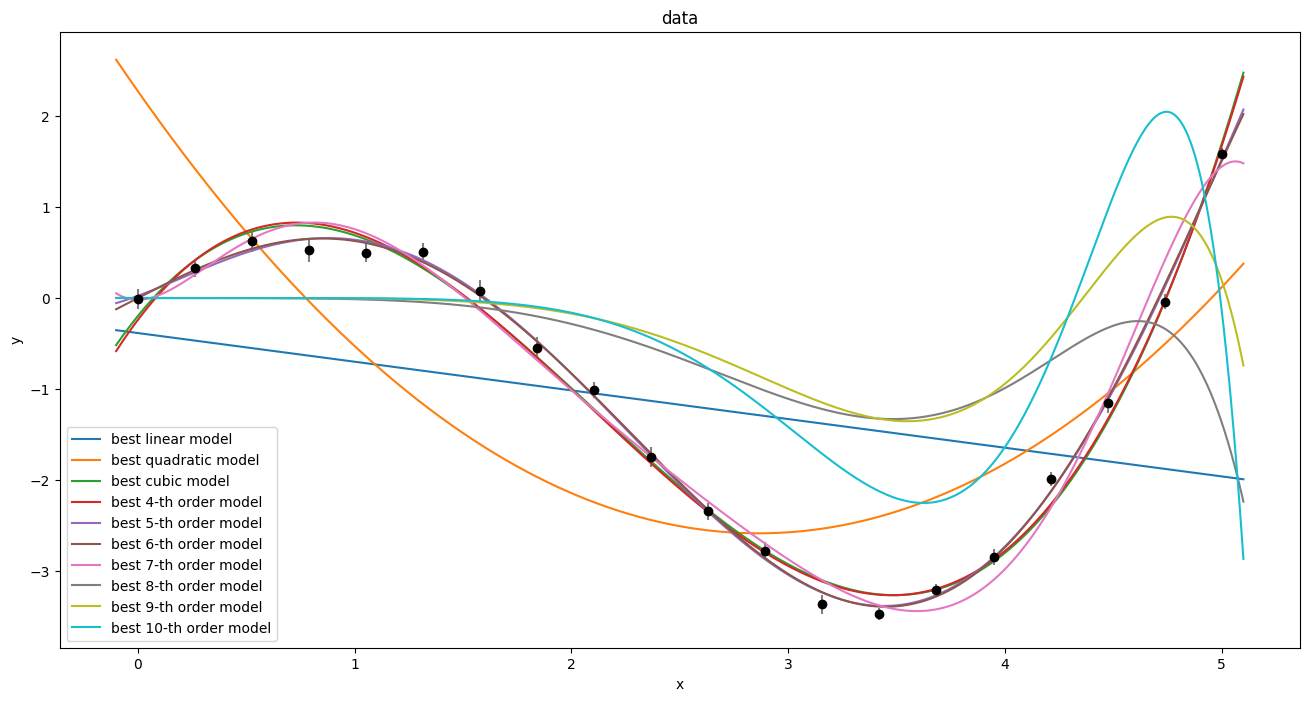

In [6]:
%matplotlib inline

# this function computes polynomial models given some data x
# and parameters theta
def polynomial_fit(theta, x):
    """Polynomial model of degree (len(theta) - 1)"""
    return sum(t * x ** n for (n, t) in enumerate(theta))

# compute the data log-likelihood given a model
def logL(theta, x, y, yErr, model=polynomial_fit):
    """Gaussian log-likelihood of the model at theta"""
    y_fit = model(theta, x)
    return sum(stats.norm.logpdf(*args)
               for args in zip(y, y_fit, yErr))

# a direct optimization approach is used to get best model 
# parameters (which minimize -logL)
def best_theta(degree, x, y, yErr, model=polynomial_fit):
    theta_0 = (degree + 1) * [0]
    neg_logL = lambda theta: -logL(theta, x, y, yErr, model)
    return optimize.fmin_bfgs(neg_logL, theta_0, disp=False)

# get best-fit parameters for linear, quadratic and cubic models
theta1 = best_theta(1, x, y, yErr)
theta2 = best_theta(2, x, y, yErr)
theta3 = best_theta(3, x, y, yErr)
theta4 = best_theta(4, x, y, yErr)
theta5 = best_theta(5, x, y, yErr)
theta6 = best_theta(6, x, y, yErr)
theta7 = best_theta(7, x, y, yErr)
theta8 = best_theta(8, x, y, yErr)
theta9 = best_theta(9, x, y, yErr)
theta10 = best_theta(10, x, y, yErr)


# generate best fit lines on a fine grid 
xfit = np.linspace(-0.1, 5.1, 1000)
yfit1 = polynomial_fit(theta1, xfit)
yfit2 = polynomial_fit(theta2, xfit)
yfit3 = polynomial_fit(theta3, xfit)
yfit4 = polynomial_fit(theta4, xfit)
yfit5 = polynomial_fit(theta5, xfit)
yfit6 = polynomial_fit(theta6, xfit)
yfit7 = polynomial_fit(theta7, xfit)
yfit8 = polynomial_fit(theta8, xfit)
yfit9 = polynomial_fit(theta9, xfit)
yfit10 = polynomial_fit(theta10, xfit)


# plot 
fig, ax = plt.subplots(figsize=(16, 8))
ax.errorbar(x, y, yErr, fmt='ok', ecolor='gray')
ax.plot(xfit, yfit1, label='best linear model')
ax.plot(xfit, yfit2, label='best quadratic model')
ax.plot(xfit, yfit3, label='best cubic model')
ax.plot(xfit, yfit4, label='best 4-th order model')
ax.plot(xfit, yfit5, label='best 5-th order model')
ax.plot(xfit, yfit6, label='best 6-th order model')
ax.plot(xfit, yfit7, label='best 7-th order model')
ax.plot(xfit, yfit8, label='best 8-th order model')
ax.plot(xfit, yfit9, label='best 9-th order model')
ax.plot(xfit, yfit10, label='best 10-th order model')

ax.legend(loc='best', fontsize=10)
ax.set(xlabel='x', ylabel='y', title='data')
plt.show();

In [ ]:
chi21 = np.sum(((y-polynomial_fit(theta1, x))/yErr)**2) 
chi22 = np.sum(((y-polynomial_fit(theta2, x))/yErr)**2) 
chi23 = np.sum(((y-polynomial_fit(theta3, x))/yErr)**2) 
chi24 = np.sum(((y-polynomial_fit(theta4, x))/yErr)**2) 
chi25 = np.sum(((y-polynomial_fit(theta5, x))/yErr)**2) 
chi26 = np.sum(((y-polynomial_fit(theta6, x))/yErr)**2) 
chi27 = np.sum(((y-polynomial_fit(theta7, x))/yErr)**2) 
chi28 = np.sum(((y-polynomial_fit(theta8, x))/yErr)**2) 
chi29 = np.sum(((y-polynomial_fit(theta9, x))/yErr)**2) 
chi210 = np.sum(((y-polynomial_fit(theta10, x))/yErr)**2) 

Ndata = np.size(x)
BIC1 = chi21 + 2*np.log(Ndata)
BIC2 = chi22 + 3*np.log(Ndata)
BIC3 = chi23 + 4*np.log(Ndata)
BIC4 = chi24 + 5*np.log(Ndata)
BIC5 = chi25 + 6*np.log(Ndata)
BIC6 = chi26 + 7*np.log(Ndata)
BIC7 = chi27 + 8*np.log(Ndata)
BIC8 = chi28 + 9*np.log(Ndata)
BIC9 = chi29 + 10*np.log(Ndata)
BIC10 = chi210 + 11*np.log(Ndata)

print ("         MODEL              CHI2            BIC")
print ('    best linear model:',  chi21,  BIC1)
print (' best quadratic model:',  chi22,  BIC2)
print ('     best cubic model:',  chi23,  BIC3)
print ('best 4-th order model:',  chi24,  BIC4)
print ('best 5-th order model:',  chi25,  BIC5)
print ('best 6-th order model:',  chi26,  BIC6)
print ('best 7-th order model:',  chi27,  BIC7)
print ('best 8-th order model:',  chi28,  BIC8)
print ('best 9-th order model:',  chi29,  BIC9)
print ('best 10-th order model:', chi210, BIC10)
print ("")

         MODEL              CHI2            BIC
    best linear model: 6384.903159375277 6390.894623922385
 best quadratic model: 2792.917232559902 2801.904429380564
     best cubic model: 63.35225027744173 75.3351793716577
best 4-th order model: 62.43668450510775 77.41534587287771
best 5-th order model: 18.709089256574195 36.683482897898145
best 6-th order model: 19.720894040076974 40.69101995495491
best 7-th order model: 103.08392416708524 127.04978235551717
best 8-th order model: 5917.58183007089 5944.543420532876
best 9-th order model: 5139.871373548907 5169.828696284447
best 10-th order model: 3919.7776119609634 3952.7306669700574



Based on BIC, the best model is the 5th order model.
$$\Delta BIC \equiv BIC_5 - BIC_6 = -4.01$$
$$|\Delta BIC| = 4$$
Not decisively better but "strong" evidence for being the better fit.
$$\Delta BIC \equiv BIC_5 - BIC_3 = -38.651$$
$$|\Delta BIC| = 38.651$$
The 5-th order model is decisively better than the cubic model.
Conclusion: 5-th order model is the best model for these data points.

## Problem 4

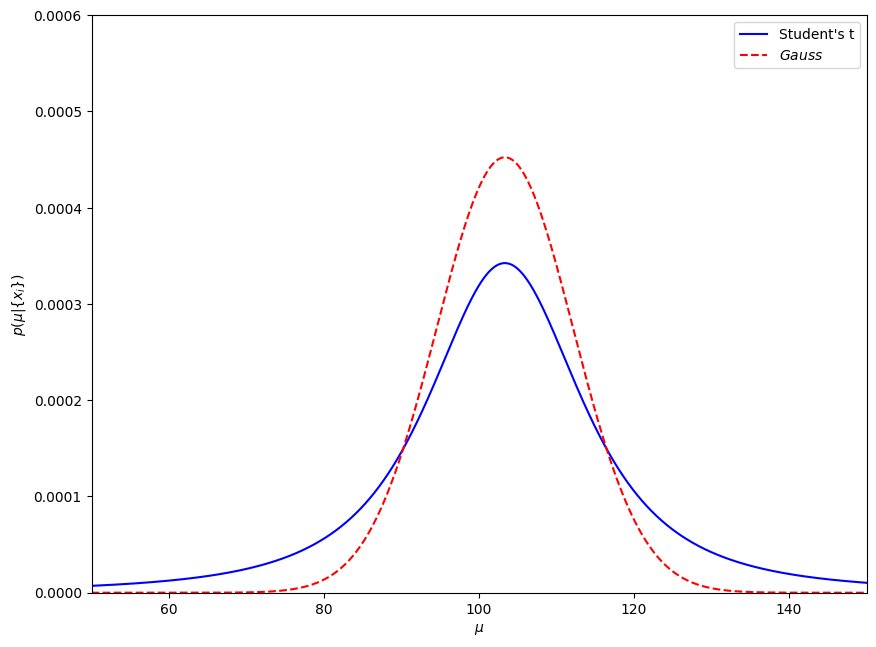

In [8]:
ast_size = [90, 100, 120]
ast_x = np.mean(ast_size)
ast_v = np.var(ast_size, ddof=1)
mu = np.linspace(50, 150, 10000)
N = 3

def compute_pmu(mu, ast_x, ast_v, N):
    p = (1 + (ast_x - mu) ** 2 / ast_v) ** (-0.5 * N)
    return p / np.sum(p)

pmu = compute_pmu(mu,ast_x,ast_v,N)
G1 = stats.norm(ast_x, np.sqrt(ast_v/N)).pdf(mu) 
G1norm = G1 / np.sum(G1)

## plot
fig, ax = plt.subplots(figsize=(10, 7.5))
plt.plot(mu, pmu, ls='-', c='blue', label="Student's t")
plt.plot(mu, G1norm, ls='--', c='red', label=r'$Gauss$')


plt.xlim(50, 150)
plt.ylim(0, 0.0006)
plt.xlabel(r'$\mu$')
plt.ylabel(r'$p(\mu|\{x_i\})$')
plt.legend()
plt.show() 

In [9]:
p_gauss = stats.norm.sf(140, loc=ast_x, scale=np.sqrt(ast_v/N))
p_t = stats.t.sf(140, df=N-1, loc=ast_x, scale=np.sqrt(ast_v/N))

print(f"Gaussian Probability > 140m: {p_gauss:.6f}")
print(f"Student's t Probability > 140m: {p_t:.6f}")

Gaussian Probability > 140m: 0.000016
Student's t Probability > 140m: 0.026635


I'll take the bet because I am 97.4% confident the asteroid is smaller than 140m.

# Problem 5

1. $$p(M|D) = \frac{p(D|M)p(M)}{p(D)}$$
2. $$p(M, \theta|D, I) = \frac{p(D|M, \theta, I)p(M, \theta|I)}{p(D|I)}$$
3. The prior probability distribution describes the probability distribution of parameter values based on existing knowledge or beliefs before considering any new data.
4. The posterior probability distribution is the probability distribution of a parameter after taking into account both the prior distribution and the new observed data.
5. $$p(\theta|M, I)$$
6. The location of the posterior probability distribution will be between the likelihood and the prior, closer to the likelihood. The width will be narrower than both the likelihood and the prior.
7. We adopt a uniform (flat) prior for location parameters, and $\frac{1}{\theta}$ for scale parameters.
8. Nuisance parameters are unknown variables in a model that must be estimated but are not of primary interest to the question being asked.
9. We can marginalize over an unknown variable (when it is a nuisance parameter) by integrating the joint probability distribution over that variable in order to solve for the specific parameter we are investigating.
10. The derivatives of each parameter can give the estimate of the parameter by seting the derivatives to zero. Second derivatives tell you the curvature, which is the uncertainty in this case.
11. If its normalized, the integral of pdf should be 1, if not normalized, it should give you the probability of data given model.
12. BIC combines Chi-square with a penalty for the complexity of a model. The model with the smallest BIC value is preferred. The difference in BIC between two models can also tell you if one is strongly favored over the other.